In [1]:
import os
import h5py
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import yaml
import optax

In [42]:
import sys
sys.path.append('/Users/mariana/Documents/projects/Huawei/survan')

from lambda_cox import LambdaSA
from baseline_cox import SA
from utils import concordance_index, unroll, get_single_task_dataset

In [43]:
def score(beta, xs):
    return -jnp.dot(xs, beta)

In [44]:
config_path = '../config.yaml'
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)

agent = SA(config, 42)

In [45]:
# TODO: ts as in baseline
agent.config.weight_decay

0.0001

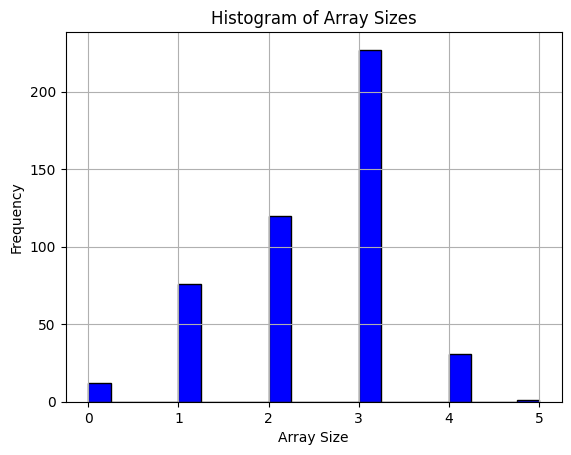

In [46]:
sizes = agent.data['ts']

# Create a histogram of the sizes
plt.hist(sizes, bins=20, color='blue', edgecolor='black')
plt.xlabel('Array Size')
plt.ylabel('Frequency')
plt.title('Histogram of Array Sizes')
plt.grid(True)

# Show the histogram
plt.show()


In [47]:
agent = SA(config, 42)
train_gen, test_gen = agent.get_train_test()

In [48]:
losses = agent.train(train_gen, test_gen)

In [49]:
train_loss, test_loss = losses

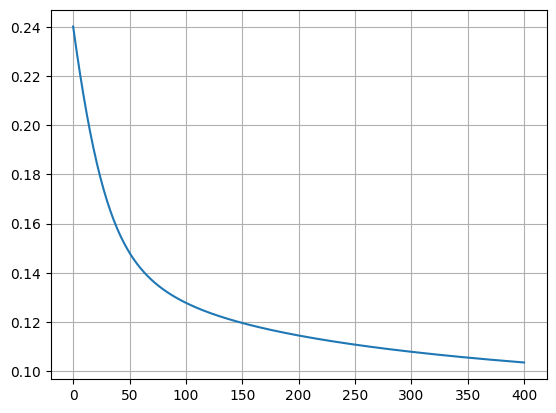

In [50]:
plt.plot(np.hstack(train_loss))
plt.grid()

In [51]:
agent.data['seqs'].shape

(467, 5, 5)

In [52]:
%%time

num_exps = 5
sizes = [.5, .3, .2, .1, .05]

res2_is = np.zeros((num_exps, len(sizes)))
res2_lm = np.zeros((num_exps, len(sizes)))

res3_is = np.zeros((num_exps, len(sizes)))
res3_lm = np.zeros((num_exps, len(sizes)))

for fold in range(num_exps):
    for i, size in enumerate(sizes):
        
        print(".", end="")
        
        # Initial state.
        config['landmark'] = False
        model = SA(config, seed=fold)
        
        train_gen, test_gen = model.get_train_test(test_size=size)
        seqs = test_gen.X
        ts = test_gen.ts
        cs = test_gen.cs
        
        _ = model.train(train_gen, test_gen)
        res2_is[fold, i] = model.integrated_brier_score(seqs[:, 0], ts, cs)
        beta = model.state.params['cox_linear_model']['beta']
        scores = score(beta, seqs[:, 0])
        res3_is[fold, i] = concordance_index(scores, ts, cs)
        
        # Landmarking.
        config['landmark'] = True
        model = SA(config, seed=fold)
        
        train_gen, test_gen = model.get_train_test(test_size=size)
        seqs = test_gen.X
        ts = test_gen.ts
        cs = test_gen.cs
        
        _ = model.train(train_gen, test_gen)
        res2_lm[fold, i] = model.integrated_brier_score(seqs[:, 0], ts, cs)
        beta = model.state.params['cox_linear_model']['beta']
        scores = score(beta, seqs[:, 0])
        res3_lm[fold, i] = concordance_index(scores, ts, cs)
        
    print()

.....
.....
.....
.....
.....
CPU times: user 1min 20s, sys: 700 ms, total: 1min 21s
Wall time: 1min 20s


Text(0.5, 0, 'Test size proportion')

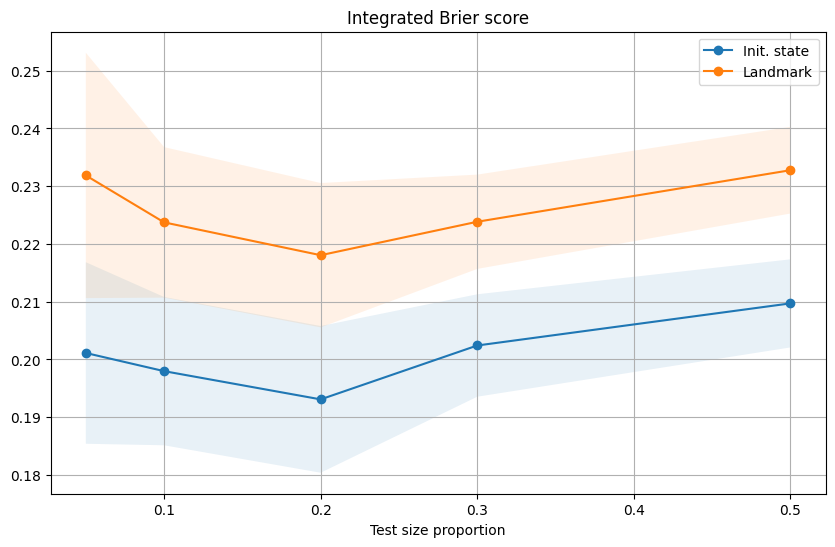

In [53]:
fig, ax = plt.subplots(figsize=(10, 6))

for res, label in ((res2_is, "Init. state"), (res2_lm, "Landmark")):
    mean = res.mean(axis=0)
    std = res.std(axis=0) / np.sqrt(num_exps)
    ax.plot(sizes, mean, marker="o", label=label)
    ax.fill_between(sizes, mean - std, mean + std, alpha=0.1)

ax.legend()
ax.grid()
ax.set_title("Integrated Brier score")
ax.set_xlabel("Test size proportion")

Text(0.5, 0, 'Number of patients')

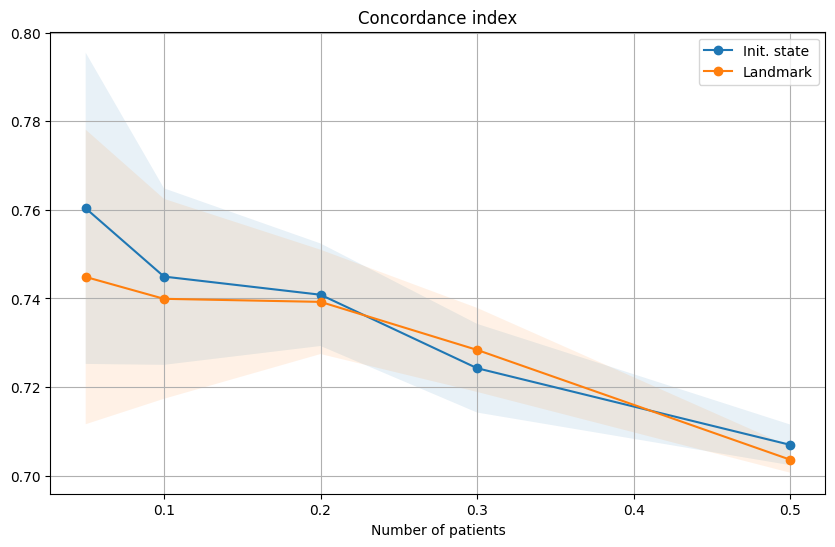

In [54]:
fig, ax = plt.subplots(figsize=(10, 6))

for res, label in ((res3_is, "Init. state"), (res3_lm, "Landmark")):
    mean = res.mean(axis=0)
    std = res.std(axis=0) / np.sqrt(num_exps)
    ax.plot(sizes, mean, marker="o", label=label)
    ax.fill_between(sizes, mean - std, mean + std, alpha=0.1)

ax.legend()
ax.grid()
ax.set_title("Concordance index")
ax.set_xlabel("Number of patients")

In [34]:
model.state.params

{'cox_linear_model': {'alpha': Array([-0.93386304, -1.0884421 , -1.3277177 , -1.5811073 , -1.5811052 ],      dtype=float32),
  'beta': Array([-0.5586684, -0.5310614, -0.5107093, -0.7165392, -0.7062951],      dtype=float32)}}